In [1]:
!pip -q install pytorch-forecasting pytorch-lightning pandas numpy scikit-learn pytorch-optimizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/BTC_Forecaster/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='lightning.pytorch')

In [4]:
df_raw = pd.read_csv("btc_data.csv")
df_raw.shape

(7515048, 6)

In [53]:
df_raw["date"] = pd.to_datetime(df_raw["Timestamp"], unit='s')

#filter from 2017 to present
df_filtered = df_raw[df_raw['date'] >= "2017-01-01"].copy()
df_filtered.set_index("date", inplace=True)

df_daily = df_filtered.resample('D').agg({
    "Open":"first",
    "High":"max",
    "Low":"min",
    "Close":"last",
    "Volume":"sum"
})
df_daily.dropna(inplace=True)
df_daily.reset_index(inplace=True)

df_daily.columns = [col.lower() for col in df_daily.columns]

#Feature Engineering

In [55]:
df_daily["log_returns"] = np.log(df_daily['close'] / df_daily['close'].shift(1))
df_daily["volatility_7d"] = df_daily["log_returns"].rolling(window=7).std()
df_daily.dropna(inplace=True)

In [56]:
df_daily["day_of_week"] = df_daily["date"].dt.dayofweek.astype(str)

#Add RSI (Relative Strength Index)
delta = df_daily["close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain/loss
df_daily["rsi_14"] = 100 - (100 / (1+rs))
df_daily.bfill(inplace=True)

#Preparing the data for TFT

In [57]:
df_daily["time_idx"] = np.arange(len(df_daily))
df_daily["group"] = "BTC"

max_encoder_length = 30
max_prediction_length = 7

training_cutoff = df_daily["time_idx"].max() - max_prediction_length - 100
training_dataset = TimeSeriesDataSet(df_daily[lambda x : x.time_idx <= training_cutoff],
                                     time_idx="time_idx",
                                     target="log_returns",
                                     group_ids=["group"],
                                     min_encoder_length=max_encoder_length//2,
                                     max_encoder_length=max_encoder_length,
                                     min_prediction_length=1,
                                     max_prediction_length=max_prediction_length,
                                     static_categoricals=["group"],
                                     time_varying_known_categoricals=["day_of_week"],
                                     time_varying_known_reals=["time_idx"],
                                     time_varying_unknown_reals=["log_returns", "close", "volatility_7d", "volume", "rsi_14"],
                                     add_relative_time_idx=True,
                                     add_target_scales=True,
                                     add_encoder_length=True)
validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    df_daily,
    predict=False,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True
)
batch_size = 64
train_dataloader = training_dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=2)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size= batch_size*2, num_workers=2)

#BASELINE TFT

In [58]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE, MAE
from pytorch_optimizer import Ranger

In [65]:
train = False

checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename="tft-baseline-{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)
if train:
  early_stop_callback = EarlyStopping(
      monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min"
  )

  trainer = pl.Trainer(
      max_epochs=30,
      accelerator="auto",
      callbacks=[checkpoint_callback, early_stop_callback],
      gradient_clip_val=0.1,
  )

  tft_baseline = TemporalFusionTransformer.from_dataset(
      training_dataset,
      learning_rate=1e-3,
      hidden_size=64,
      attention_head_size=4,
      dropout=0.1,
      hidden_continuous_size=8,
      loss=RMSE(),
      optimizer=Ranger,
      reduce_on_plateau_patience=4,
  )
  trainer.fit(
      tft_baseline,
      train_dataloaders=train_dataloader,
      val_dataloaders=val_dataloader,
  )
else:
  CHECKPOINT_FILENAME = "tft-baseline-epoch=00-val_loss=0.0287.ckpt"
  BEST_CHECKPOINT_PATH = os.path.join("/content/drive/MyDrive/BTC_Forecaster/checkpoints/", CHECKPOINT_FILENAME)
  if os.path.exists(BEST_CHECKPOINT_PATH):
      print(f"✅ Bypassing training. Loading optimized weights from: {CHECKPOINT_FILENAME}")

      # put the model in eval mode (freezes weights)
      best_tft = TemporalFusionTransformer.load_from_checkpoint(BEST_CHECKPOINT_PATH)
      best_tft.eval()

  else:
      raise FileNotFoundError(f"❌ Could not find {BEST_CHECKPOINT_PATH}. Check your Colab files!")

✅ Bypassing training. Loading optimized weights from: tft-baseline-epoch=00-val_loss=0.0287.ckpt


In [66]:
#Load the best weights
if train:
  best_model_path = checkpoint_callback.best_model_path
  best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Generate predictions
predictions = best_tft.predict(val_dataloader, mode="prediction", return_y=True)

y_pred_returns = predictions.output[:, 0].cpu().numpy()
y_true_returns = predictions.y[0][:, 0].cpu().numpy()

# Calculate Regression Metrics on Returns
mae = mean_absolute_error(y_true_returns, y_pred_returns)
rmse = np.sqrt(mean_squared_error(y_true_returns, y_pred_returns))
r2 = r2_score(y_true_returns, y_pred_returns)

#Calculate Directional Accuracy
direction_true = np.sign(y_true_returns)
direction_pred = np.sign(y_pred_returns)
valid_idx = direction_true != 0
dir_acc = np.mean(direction_true[valid_idx] == direction_pred[valid_idx])

#PORTFOLIO RISK METRICS
# Generate Trading Signals (Long = +1, Short = -1)
trading_signals = np.sign(y_pred_returns)

# Calculate Strategy Returns
strategy_log_returns = trading_signals * y_true_returns

# Calculate Annualized Sharpe Ratio (Assuming 365 trading days for Crypto)
mean_daily_return = np.mean(strategy_log_returns)
std_daily_return = np.std(strategy_log_returns)

if std_daily_return > 0:
    annualized_sharpe = (mean_daily_return / std_daily_return) * np.sqrt(365)
else:
    annualized_sharpe = 0.0

# Calculate Maximum Drawdown (MDD)
equity_curve = np.exp(np.cumsum(strategy_log_returns))

# Track the highest peak the portfolio has ever reached
rolling_max = np.maximum.accumulate(equity_curve)

# Calculate the percentage drop from the highest peak
drawdowns = (equity_curve - rolling_max) / rolling_max
max_drawdown = np.min(drawdowns)


print("--- STATIONARY TFT EVALUATION (LOG RETURNS) ---")
print(f"MAE (Avg % Error): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Directional Accuracy: {dir_acc:.2%}")
print("-" * 45)
print("--- PORTFOLIO RISK METRICS ---")
print(f"Annualized Sharpe Ratio: {annualized_sharpe:.4f}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Total Strategy Cumulative Return: {(equity_curve[-1] - 1.0):.2%}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

--- STATIONARY TFT EVALUATION (LOG RETURNS) ---
MAE (Avg % Error): 0.0190
RMSE: 0.0279
R2 Score: -0.0386
Directional Accuracy: 63.28%
---------------------------------------------
--- PORTFOLIO RISK METRICS ---
Annualized Sharpe Ratio: 1.6122
Maximum Drawdown: -14.72%
Total Strategy Cumulative Return: 34.22%


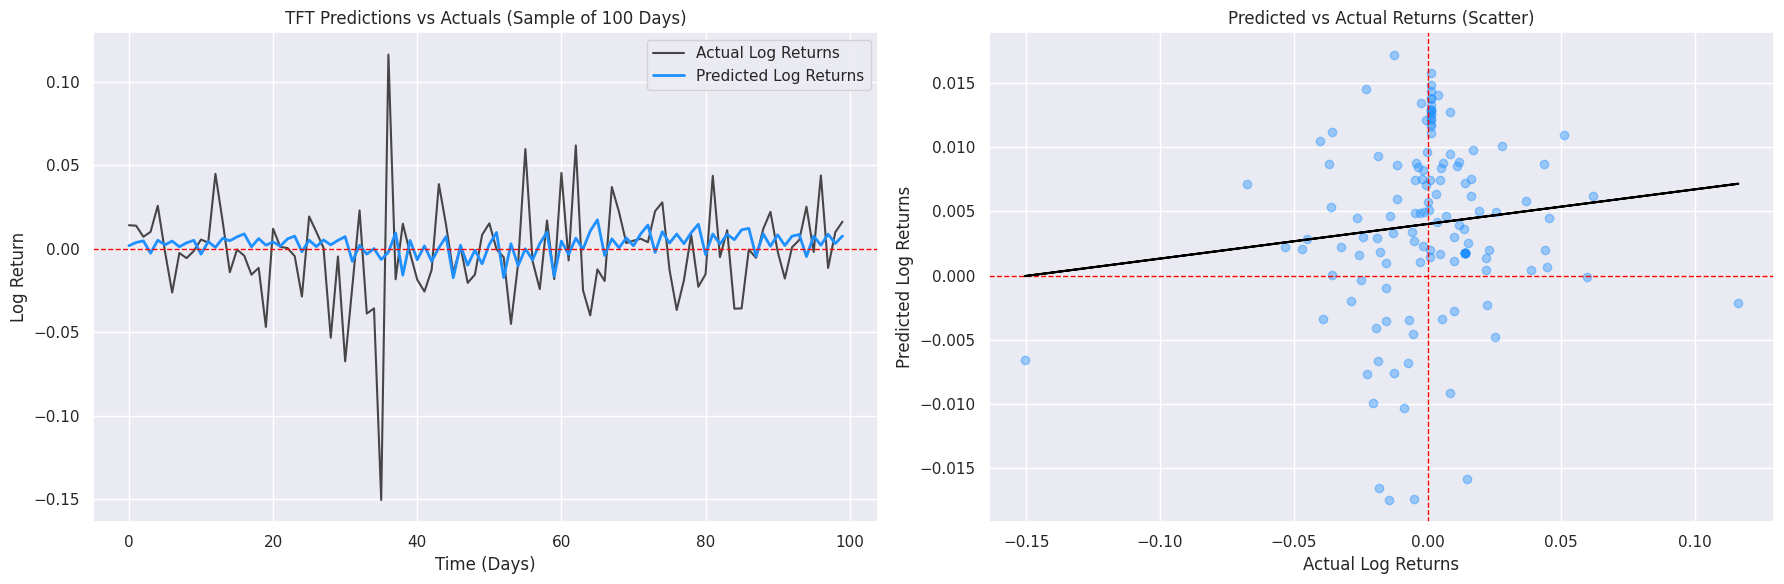

In [67]:
sns.set_theme(style="darkgrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_length = 100
axes[0].plot(y_true_returns[:plot_length], label="Actual Log Returns", color="black", linewidth=1.5, alpha=0.7)
axes[0].plot(y_pred_returns[:plot_length], label="Predicted Log Returns", color="dodgerblue", linewidth=2)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1) # The zero-line (Directional pivot)
axes[0].set_title(f"TFT Predictions vs Actuals (Sample of {plot_length} Days)")
axes[0].set_xlabel("Time (Days)")
axes[0].set_ylabel("Log Return")
axes[0].legend()

# --- Plot 2: Scatter Plot (The Outlier Problem) ---
# This visually explains R2 score
axes[1].scatter(y_true_returns, y_pred_returns, alpha=0.4, color="dodgerblue")
axes[1].axvline(0, color='red', linestyle='--', linewidth=1) # Vertical zero line
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

m, b = np.polyfit(y_true_returns, y_pred_returns, 1)
axes[1].plot(y_true_returns, m*y_true_returns + b, color="black", linestyle="-")

axes[1].set_title("Predicted vs Actual Returns (Scatter)")
axes[1].set_xlabel("Actual Log Returns")
axes[1].set_ylabel("Predicted Log Returns")

plt.tight_layout()
plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

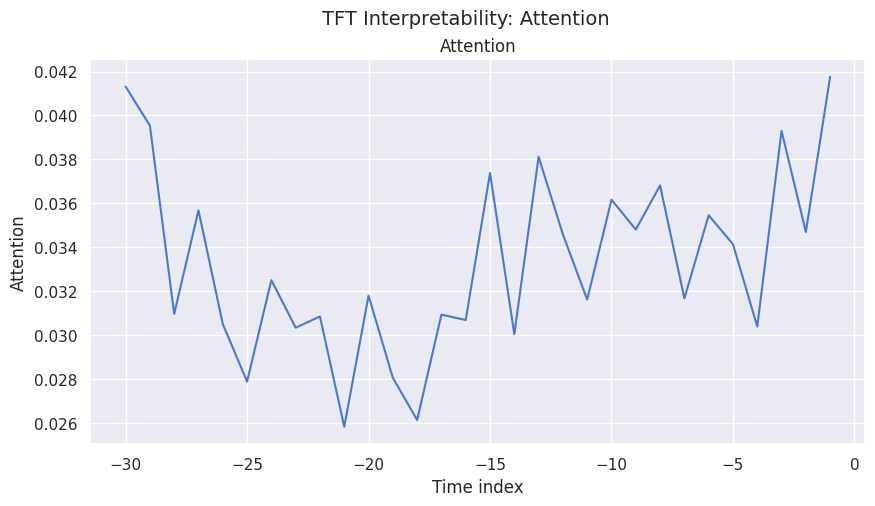

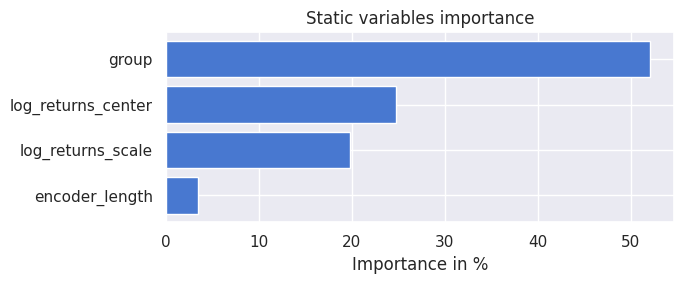

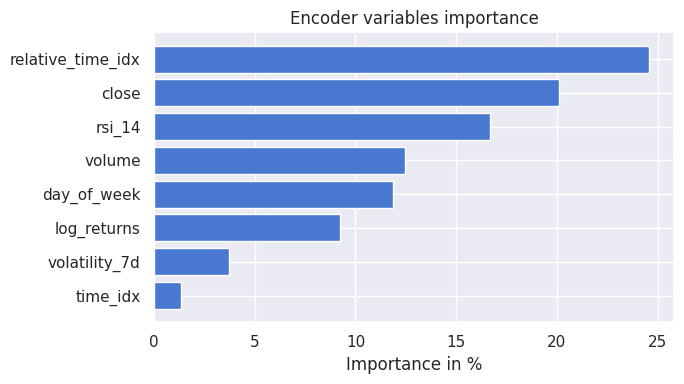

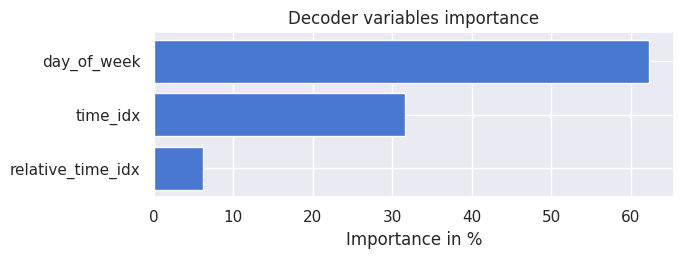

In [68]:
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)

# Calculate the feature interpretations across the entire validation set
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")

# Plot Variable Importance
fig = best_tft.plot_interpretation(interpretation)

for key, figure in fig.items():
    figure.set_size_inches(10, 5)
    figure.suptitle(f"TFT Interpretability: {key.replace('_', ' ').title()}", fontsize=14)
    plt.show()

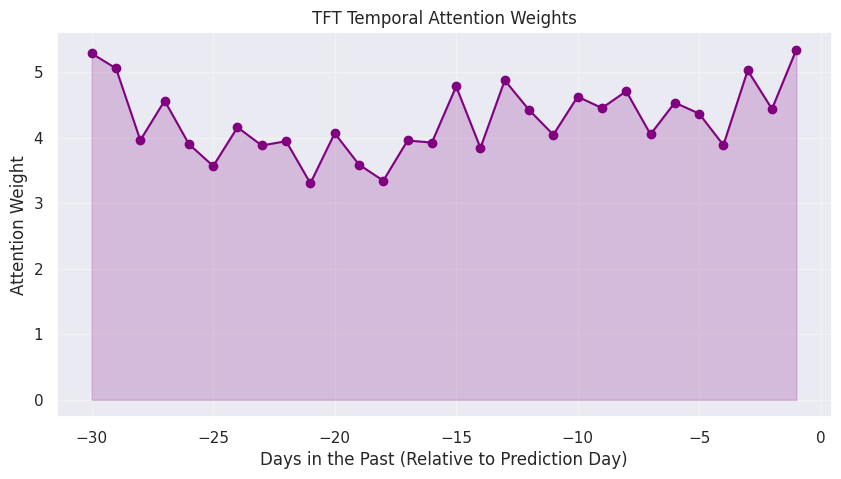

In [69]:
attention_weights = interpretation["attention"]

plt.figure(figsize=(10, 5))
# attention_weights represents the weight given to past days.
plt.plot(range(-len(attention_weights), 0), attention_weights.cpu().numpy(), marker="o", color="purple")
plt.title("TFT Temporal Attention Weights")
plt.xlabel("Days in the Past (Relative to Prediction Day)")
plt.ylabel("Attention Weight")
plt.fill_between(range(-len(attention_weights), 0), attention_weights.cpu().numpy(), color="purple", alpha=0.2)
plt.grid(True, alpha=0.3)
plt.show()

#Improved TFT with additional architectural changes 🚀

In [70]:
import torch.optim as optim

In [71]:
# ── Shared evaluation helper (used by all improved models) ───────────────────
def evaluate_model(model, val_dataloader, model_name="Model"):
    """Run full evaluation suite: regression metrics + portfolio risk metrics."""
    model.eval()
    predictions = model.predict(val_dataloader, mode="prediction", return_y=True)

    # Extract ONLY the 1-step ahead forecast to avoid NaN padding at the dataset edge
    y_pred = predictions.output[:, 0].cpu().numpy()
    y_true = predictions.y[0][:, 0].cpu().numpy()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    dir_true = np.sign(y_true)
    dir_pred = np.sign(y_pred)
    valid_idx = dir_true != 0
    dir_acc  = np.mean(dir_true[valid_idx] == dir_pred[valid_idx])

    signals = np.sign(y_pred)
    strat_returns = signals * y_true
    mean_ret = np.mean(strat_returns)
    std_ret  = np.std(strat_returns)
    sharpe   = (mean_ret / std_ret) * np.sqrt(365) if std_ret > 0 else 0.0

    equity_curve = np.exp(np.cumsum(strat_returns))
    rolling_max  = np.maximum.accumulate(equity_curve)
    drawdowns    = (equity_curve - rolling_max) / rolling_max
    mdd          = np.min(drawdowns)

    print(f"\n{'='*50}")
    print(f"  {model_name} — EVALUATION RESULTS")
    print(f"{'='*50}")
    print(f"  MAE:                  {mae:.4f}")
    print(f"  RMSE:                 {rmse:.4f}")
    print(f"  R² Score:             {r2:.4f}")
    print(f"  Directional Accuracy: {dir_acc:.2%}")
    print(f"  Annualized Sharpe:    {sharpe:.4f}")
    print(f"  Max Drawdown:         {mdd:.2%}")
    print(f"  Cumulative Return:    {(equity_curve[-1]-1.0):.2%}")
    print(f"{'='*50}")

    return {
        "y_true": y_true, "y_pred": y_pred,
        "mae": mae, "rmse": rmse, "r2": r2,
        "dir_acc": dir_acc, "sharpe": sharpe, "mdd": mdd,
        "equity_curve": equity_curve,
    }


def plot_predictions(results, model_name="Model", color="dodgerblue"):
    """Two-panel plot: time-series overlay + scatter."""
    sns.set_theme(style="darkgrid", palette="muted")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plot_len = 100
    y_true, y_pred = results["y_true"], results["y_pred"]

    axes[0].plot(y_true[:plot_len], label="Actual",    color="black",  lw=1.5, alpha=0.7)
    axes[0].plot(y_pred[:plot_len], label="Predicted", color=color,    lw=2)
    axes[0].axhline(0, color="red", ls="--", lw=1)
    axes[0].set_title(f"{model_name}: Predictions vs Actuals (sample {plot_len} days)")
    axes[0].set_xlabel("Time (Days)"); axes[0].set_ylabel("Log Return")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, alpha=0.4, color=color)
    axes[1].axvline(0, color="red", ls="--", lw=1)
    axes[1].axhline(0, color="red", ls="--", lw=1)
    m, b = np.polyfit(y_true, y_pred, 1)
    axes[1].plot(y_true, m*y_true + b, color="black")
    axes[1].set_title(f"{model_name}: Predicted vs Actual (Scatter)")
    axes[1].set_xlabel("Actual Log Returns"); axes[1].set_ylabel("Predicted Log Returns")

    plt.tight_layout(); plt.show()


In [72]:
# ── Checkpoint directories for each improved model ───────────────────────────
BASE_SAVE_DIR = '/content/drive/MyDrive/BTC_Forecaster/improved_tft'

REGIME_DIR         = os.path.join(BASE_SAVE_DIR, 'regimeAwareTFT')
REGIME_VOL_DIR     = os.path.join(BASE_SAVE_DIR, 'regimeAndVolatilityAwareTFT')
FINAL_BOSS_DIR     = os.path.join(BASE_SAVE_DIR, 'finalBossTFT')

for d in [REGIME_DIR, REGIME_VOL_DIR, FINAL_BOSS_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"✅  {d}")


✅  /content/drive/MyDrive/BTC_Forecaster/improved_tft/regimeAwareTFT
✅  /content/drive/MyDrive/BTC_Forecaster/improved_tft/regimeAndVolatilityAwareTFT
✅  /content/drive/MyDrive/BTC_Forecaster/improved_tft/finalBossTFT


In [76]:
# ── Architecture: RegimeAwareTFT ─────────────────────────────────────────────
# Strategy: register a forward hook on TFT's internal LSTM encoder to capture
# hidden states, then add a regime embedding as a residual to the captured
# encoder output BEFORE the decoder attention sees it.

import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_forecasting import TemporalFusionTransformer


class MarketRegimeDetector(nn.Module):
    """
    GRU that reads encoder hidden states → soft regime embedding.
    Input : (B, T_enc, D)
    Output: regime_embed (B, D)  — added back as a residual
    """
    def __init__(self, input_size: int, hidden_size: int = 32, num_regimes: int = 3):
        super().__init__()
        self.gru   = nn.GRU(input_size, hidden_size, batch_first=True)
        self.clf   = nn.Linear(hidden_size, num_regimes)
        self.embed = nn.Embedding(num_regimes, input_size)

    def forward(self, encoder_output: torch.Tensor):
        _, h_n  = self.gru(encoder_output)
        h       = h_n.squeeze(0)
        logits  = self.clf(h)
        probs   = F.softmax(logits, dim=-1)
        regime_embed = probs @ self.embed.weight
        return logits, regime_embed


class RegimeAwareTFT(TemporalFusionTransformer):
    """
    Vanilla TFT + MarketRegimeDetector.

    We use a forward hook on the internal 'encoder' LSTM so we can:
      1. Capture its output right after it runs.
      2. Compute a regime embedding from it.
      3. Add the regime embedding back as a residual (modifies the tensor
         in-place so the rest of the TFT decoder sees the enriched states).
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        D = self.hparams.hidden_size
        self.regime_detector = MarketRegimeDetector(input_size=D, hidden_size=32)
        self.regime_proj     = nn.Linear(D, D)
        self._hook_handle    = None

    def _make_hook(self):
        def hook(module, input, output):
            lstm_out = output[0]
            _, regime_embed = self.regime_detector(lstm_out)
            regime_embed    = self.regime_proj(regime_embed)
            residual        = regime_embed.unsqueeze(1)
            patched         = lstm_out + residual
            return (patched, output[1])
        return hook

    def _register_hook(self):
        for name, module in self.named_modules():
            if isinstance(module, nn.LSTM) and "encoder" in name:
                self._hook_handle = module.register_forward_hook(self._make_hook())
                return
        # Fallback: attach to the very first LSTM found
        for name, module in self.named_modules():
            if isinstance(module, nn.LSTM):
                self._hook_handle = module.register_forward_hook(self._make_hook())
                return
        raise RuntimeError(
            "RegimeAwareTFT: could not find an LSTM sub-module to hook. "
            "Inspect self.named_modules() to find the correct layer name."
        )

    def _remove_hook(self):
        if self._hook_handle is not None:
            self._hook_handle.remove()
            self._hook_handle = None

    def forward(self, x: dict):
        self._register_hook()
        try:
            out = super().forward(x)
        finally:
            self._remove_hook()
        return out


In [77]:
#Train / Load: regimeAwareTFT
from pytorch_forecasting.metrics import RMSE
from pytorch_optimizer import Ranger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

train_regime = False

checkpoint_regime = ModelCheckpoint(
    dirpath=REGIME_DIR,
    filename="regimeAwareTFT-{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)

if train_regime:
    early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, mode="min")

    trainer_regime = pl.Trainer(
        max_epochs=30,
        accelerator="auto",
        callbacks=[checkpoint_regime, early_stop],
        gradient_clip_val=0.1,
    )

    regime_model = RegimeAwareTFT.from_dataset(
        training_dataset,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=8,
        loss=RMSE(),
        optimizer=Ranger,
        reduce_on_plateau_patience=4,
    )

    trainer_regime.fit(
        regime_model,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader,
    )
    best_regime_path = checkpoint_regime.best_model_path
    print(f"✅  Best checkpoint: {best_regime_path}")

else:
    REGIME_CKPT = "regimeAwareTFT-epoch=09-val_loss=0.0221.ckpt"
    best_regime_path = os.path.join(REGIME_DIR, REGIME_CKPT)

    if os.path.exists(best_regime_path):
        print(f"✅  Loading: {REGIME_CKPT}")
        regime_model = RegimeAwareTFT.load_from_checkpoint(best_regime_path)
        regime_model.eval()
    else:
        raise FileNotFoundError(f"❌  Not found: {best_regime_path}")


✅  Loading: regimeAwareTFT-epoch=09-val_loss=0.0221.ckpt


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


  regimeAwareTFT — EVALUATION RESULTS
  MAE:                  0.0174
  RMSE:                 0.0275
  R² Score:             -0.0090
  Directional Accuracy: 54.69%
  Annualized Sharpe:    2.3127
  Max Drawdown:         -16.45%
  Cumulative Return:    52.29%


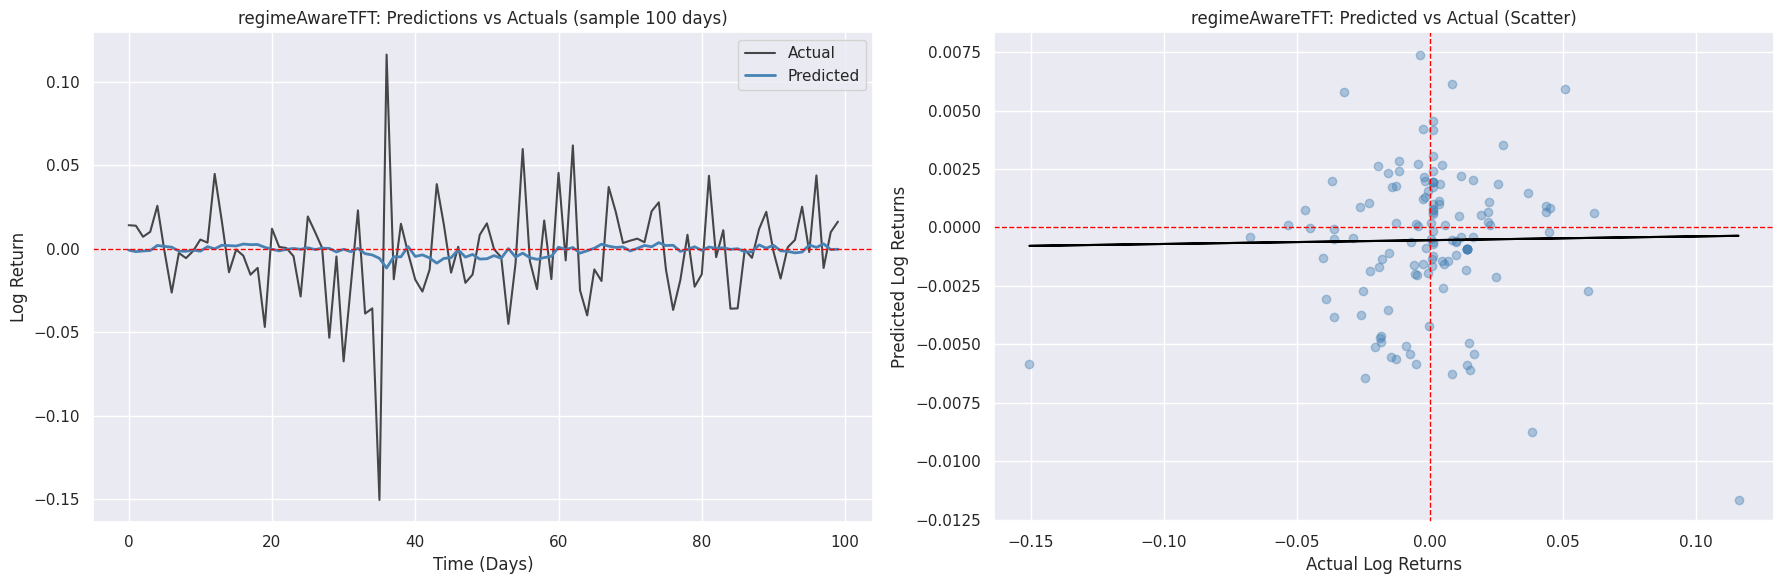

In [78]:
results_regime = evaluate_model(regime_model, val_dataloader, "regimeAwareTFT")
plot_predictions(results_regime, "regimeAwareTFT", color="steelblue")
